# FrustraMotion: Interactive User Guide
Welcome to **FrustraMotion**, a Python toolkit designed to analyze and visualize the temporal dynamics of protein frustration from Molecular Dynamics simulations.

In this tutorial, we will analyze a short trajectory of the **Mycobacterium tuberculosis Encapsulin (MtEnc)**. Our goal is to identify "hotspot" residues that act as allosteric switches and visualize how their microenvironment changes over time. 

## 1. Pre-processing. Original frustration data parsing

The original Frustratometer generates hundreds of `.done` files. Frustramotion includes a parsing tool (*Frustramotion parse*) that can read all these files and gives them the structure of a Tidy Data dataframe. 

First, we're going to parse Single Residue frustration, and then the Mutational contacts network.


In [40]:
import sys
import os
import pandas as pd
from IPython.display import Image

# 1. Path configuration (Ensure Python finds the 'src' module)
project_root = os.path.abspath("..") 
sys.path.insert(0, os.path.join(project_root, "src"))

# 2. Import FrustraMotion parsing tools
from frustramotion.parsers.single import parse_frustration_files as parse_single, save_dataframes as save_single
from frustramotion.parsers.contacts import parse_contact_files as parse_contacts, save_contact_data as save_contacts

# 3. Import Analytical & Plotting engines
from frustramotion.analysis.core import FrustrationTrajectory
from frustramotion.analysis.contact import ContactNetworkAnalyzer
from frustramotion.plotting.timeseries import plot_frustration_vs_frames
from frustramotion.plotting.contacts import plot_residue_contacts
from frustramotion.io.export_chimerax import generate_chimerax_script

# 4. Define I/O directories
RAW_DATA_DIR = "./example_data/MtEnc" 
DATA_DIR = "./example_data/dfs"
OUT_DIR = "./figs"

# Create necessary directories
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

print("[*] Setup complete. FrustraMotion environment is ready.")
# configure paths
project_root = os.path.abspath("..") 
sys.path.insert(0, os.path.join(project_root, "src"))


[*] Setup complete. FrustraMotion environment is ready.


In [41]:
# 1. Single residue frustration parsing

# This line reads the files and creates a dict
# If you have more than one chain, you can specify which chain data to parse with the argument "chains"
dfs_single = parse_single(RAW_DATA_DIR)

# Save results (This generates automatically files with the convention {protein_name}_chain_{chainID}.csv)
save_single(dfs_single, out_dir=DATA_DIR, protein_name="MtEnc")


[*] Scanning directories for frustration data...
[*] Found 21 valid frames. Processing...
[*] Assembling Tidy DataFrames...
 -> Saved: ./example_data/dfs\MtEnc_chain_A.csv (Shape: (5544, 4))


In [42]:
# 2. Contact frustration parsing (mode: Mutational)

# Read contacts in mutational mode
# If you have more than one chain, you can specify which chain data to parse with the argument "chains"

df_contacts = parse_contacts(RAW_DATA_DIR, contact_type='mutational')

# Save results
save_contacts(df_contacts, out_dir=DATA_DIR, protein_name="MtEnc", contact_type='mutational')

[*] Scanning directories for 'mutational' frustration data...
[*] Found 21 valid frames. Processing...
[*] Assembling Tidy Contact DataFrames...
[*] Saving specific contact files by chain pairs...
   -> Saved: MtEnc_mutational_chain_A_intra_contacts.csv (Shape: (31594, 8))
[*] Successfully saved 1 chain-pair files.


Pre processing completed!
Now, let's take a look inside the dataframes: 

In [43]:
single_res_df = pd.read_csv(os.path.join(DATA_DIR, 'MtEnc_chain_A.csv'))
single_res_df.head()

,Chain,Residue,Frame,FrstIndex
0,A,M1,0,0.355
1,A,N2,0,0.130
2,A,N3,0,-0.038
3,A,L4,0,1.193
4,A,Y5,0,0.689


In [44]:
contacts_df = pd.read_csv(os.path.join(DATA_DIR, 'MtEnc_mutational_chain_A_intra_contacts.csv'))
contacts_df.head()

,Frame,ChainRes1,ChainRes2,ResID1,ResID2,Welltype,FrstState,FrstIndex
0,0,A,A,A:M1,A:N3,water-mediated,neutral,-0.014
1,0,A,A,A:M1,A:L4,short,minimally,0.988
2,0,A,A,A:M1,A:Y5,short,minimally,0.852
3,0,A,A,A:M1,A:R6,water-mediated,neutral,-0.324
4,0,A,A,A:M1,A:D7,water-mediated,neutral,-0.529


We can use pandas to calculate a lot of metrics with this dataframe, for example:

In [45]:
# 1. Contact type composition (Percentage of short, long, and water-mediated interactions)
welltype_counts = contacts_df['Welltype'].value_counts(normalize=True) * 100
print("--- Contact Type Distribution ---")
print(welltype_counts.round(2).astype(str) + ' %')


# 2. Dynamic network size (Average number of contacts formed per frame)
contacts_per_frame = contacts_df.groupby('Frame').size()
print(f"\n--- Network Size ---")
print(f"Average contacts per frame: {contacts_per_frame.mean():.1f} ± {contacts_per_frame.std():.1f}")

# 3. Mean frustration index depending on the contact type
mean_frst_by_welltype = contacts_df.groupby('Welltype')['FrstIndex'].mean()
print("\n--- Mean Frustration by Contact Type ---")
print(mean_frst_by_welltype.round(3))


--- Contact Type Distribution ---
Welltype
long              47.11 %
short             28.39 %
water-mediated     24.5 %
Name: proportion, dtype: str

--- Network Size ---
Average contacts per frame: 1504.5 ± 24.3

--- Mean Frustration by Contact Type ---
Welltype
long              0.666
short             0.392
water-mediated   -0.065
Name: FrstIndex, dtype: float64


## 2. Biophysical Analysis: Discovering "Hotspots"
Instead of blindly scrolling through the trajectory, we use the `FrustrationTrajectory` analytical engine to scan the entire protein. We will calculate the **Dynamic Score** (energetic variance) to find which residues undergo the most significant conformational changes.

In [46]:
traj = FrustrationTrajectory(single_res_df)


In [47]:
# Get the Top 5 most dynamic residues (our potential switches)
hotspots = traj.get_hotspots(top_n=5)
print("[] Top 5 Hotspots (Most dynamic residues):")
display(hotspots)

# Let's save the most dynamic residue in a variable for deep analysis
top_residue = hotspots.index[0]
print(f"\n[*] Selecting residue {top_residue} for deep dive analysis.")

[] Top 5 Hotspots (Most dynamic residues):


,Dynamic_Score,mean,max,min
Residue,,,,
Y178,0.958344,-1.267952,0.771,-2.759
P168,0.925306,-0.659524,0.705,-2.163
Y255,0.924853,-1.600762,0.044,-2.860
R70,0.871680,0.173000,1.356,-0.803
R54,0.836885,0.842000,1.896,-0.807



[*] Selecting residue Y178 for deep dive analysis.


In [48]:
# Extract dwell times (percentage of time spent in each energetic state)
dwell_times = traj.get_dwell_times()

print(f"[+] Dwell times for the most dynamic residue ({top_residue}):")
# Dynamically access the top_residue instead of hardcoding 'Y178'
display(dwell_times.loc[top_residue].to_frame(name='% of Time'))


[+] Dwell times for the most dynamic residue (Y178):


,% of Time
State,
Minimally,0.000000
Neutral,28.571429
Highly,71.428571


In [49]:
# Extract flipping rate (how often the residue changes conformational state)
flipping_rate = traj.get_flipping_rate()

print(f"\n[+] Flipping rate for {top_residue}:")
display(flipping_rate.loc[top_residue].to_frame(name='Transitions'))


[+] Flipping rate for Y178:


,Transitions
Total_Transitions,9.000000
Flipping_Rate,0.428571


You can also explore other metrics in the *frustramotion analyze* package, including:
- Hotspots
- Dwell times (% of time spent in each frustration state)
- Shannon entropy
- Flipping rate (transitions between states)
- Persistence (max streaks in frustration state)
- Transitions (detects energy jumps in a frame window)

In [50]:
# Initialize the analyzer with the filtered Chain A contacts DataFrame
# Note: We use 'contacts_df' loaded previously, not the raw parser output
net_analyzer = ContactNetworkAnalyzer(contacts_df)

# --- Metric 1: Frustration Hubs ---
# Identifies residues that accumulate the highest number of frustrated contacts
print("[+] Top 5 Frustration Hubs (Structural stress centers):")
hubs = net_analyzer.get_frustration_hubs(top_n=5)
display(hubs)

# --- Metric 2: Hot Edges ---
# Identifies specific residue pairs that maintain highly stressed interactions
print("\n[+] Top 5 Hot Edges (Most persistently frustrated connections):")
hot_edges = net_analyzer.get_frustration_hot_edges(top_n=5)
display(hot_edges)

[+] Top 5 Frustration Hubs (Structural stress centers):


,Avg_Highly_Frustrated_Contacts_Per_Frame
ResID1,
A:D223,10.333333
A:D221,9.190476
A:P146,7.904762
A:E129,7.095238
A:E88,7.000000



[+] Top 5 Hot Edges (Most persistently frustrated connections):


,Mean_FrstIndex,Predominant_Welltype,Persistence
PairID,,,
A:E102_A:E88,-2.139333,water-mediated,0.285714
A:D100_A:E88,-2.106333,water-mediated,0.714286
A:D229_A:P42,-2.038333,long,1.000000
A:D221_A:D223,-1.989000,water-mediated,1.000000
A:D223_A:K73,-1.974524,long,1.000000


## 3. Visualizing The Energy Landscape
Now that we have identified our main hotspot, we will plot the temporal frustration series.

In [12]:
from frustramotion.plotting.timeseries import plot_frustration_vs_frames
from IPython.display import Image

OUT_DIR = "./figs"
os.makedirs(OUT_DIR, exist_ok=True)

 -> Saved plot successfully: ./figs\timeseries_chain_A_res_Y178.png

------------------------------
Residue Y178 Profile:
- Minimally Frustrated: 0.0%
- Highly Frustrated: 71.4%
- Neutral: 28.6%
------------------------------



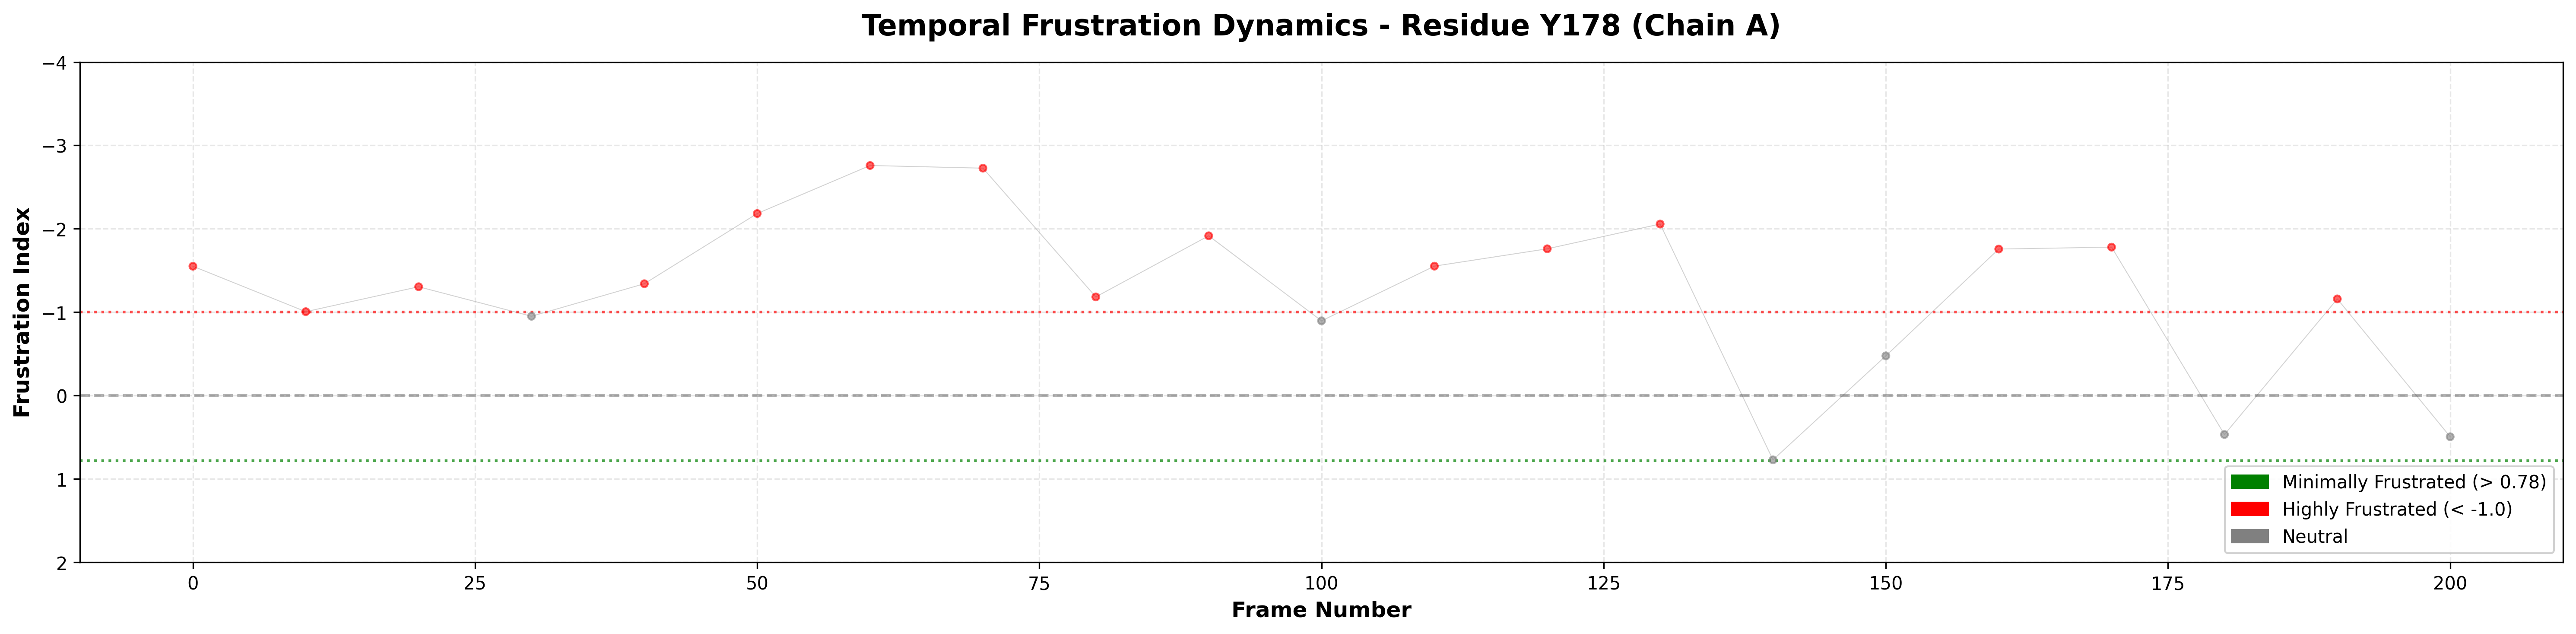

In [13]:
plot_frustration_vs_frames(
    df=single_res_df, 
    residue_id=top_residue, 
    chain_id='A', 
    out_dir=OUT_DIR
)

Image(filename=f"{OUT_DIR}/timeseries_chain_A_res_{top_residue}.png")

In [ ]:
from frustramotion.plotting.contacts import plot_residue_contacts

 -> Saved Contact Dashboard: ./figs\contact_dashboard_A_Y178_intra.png


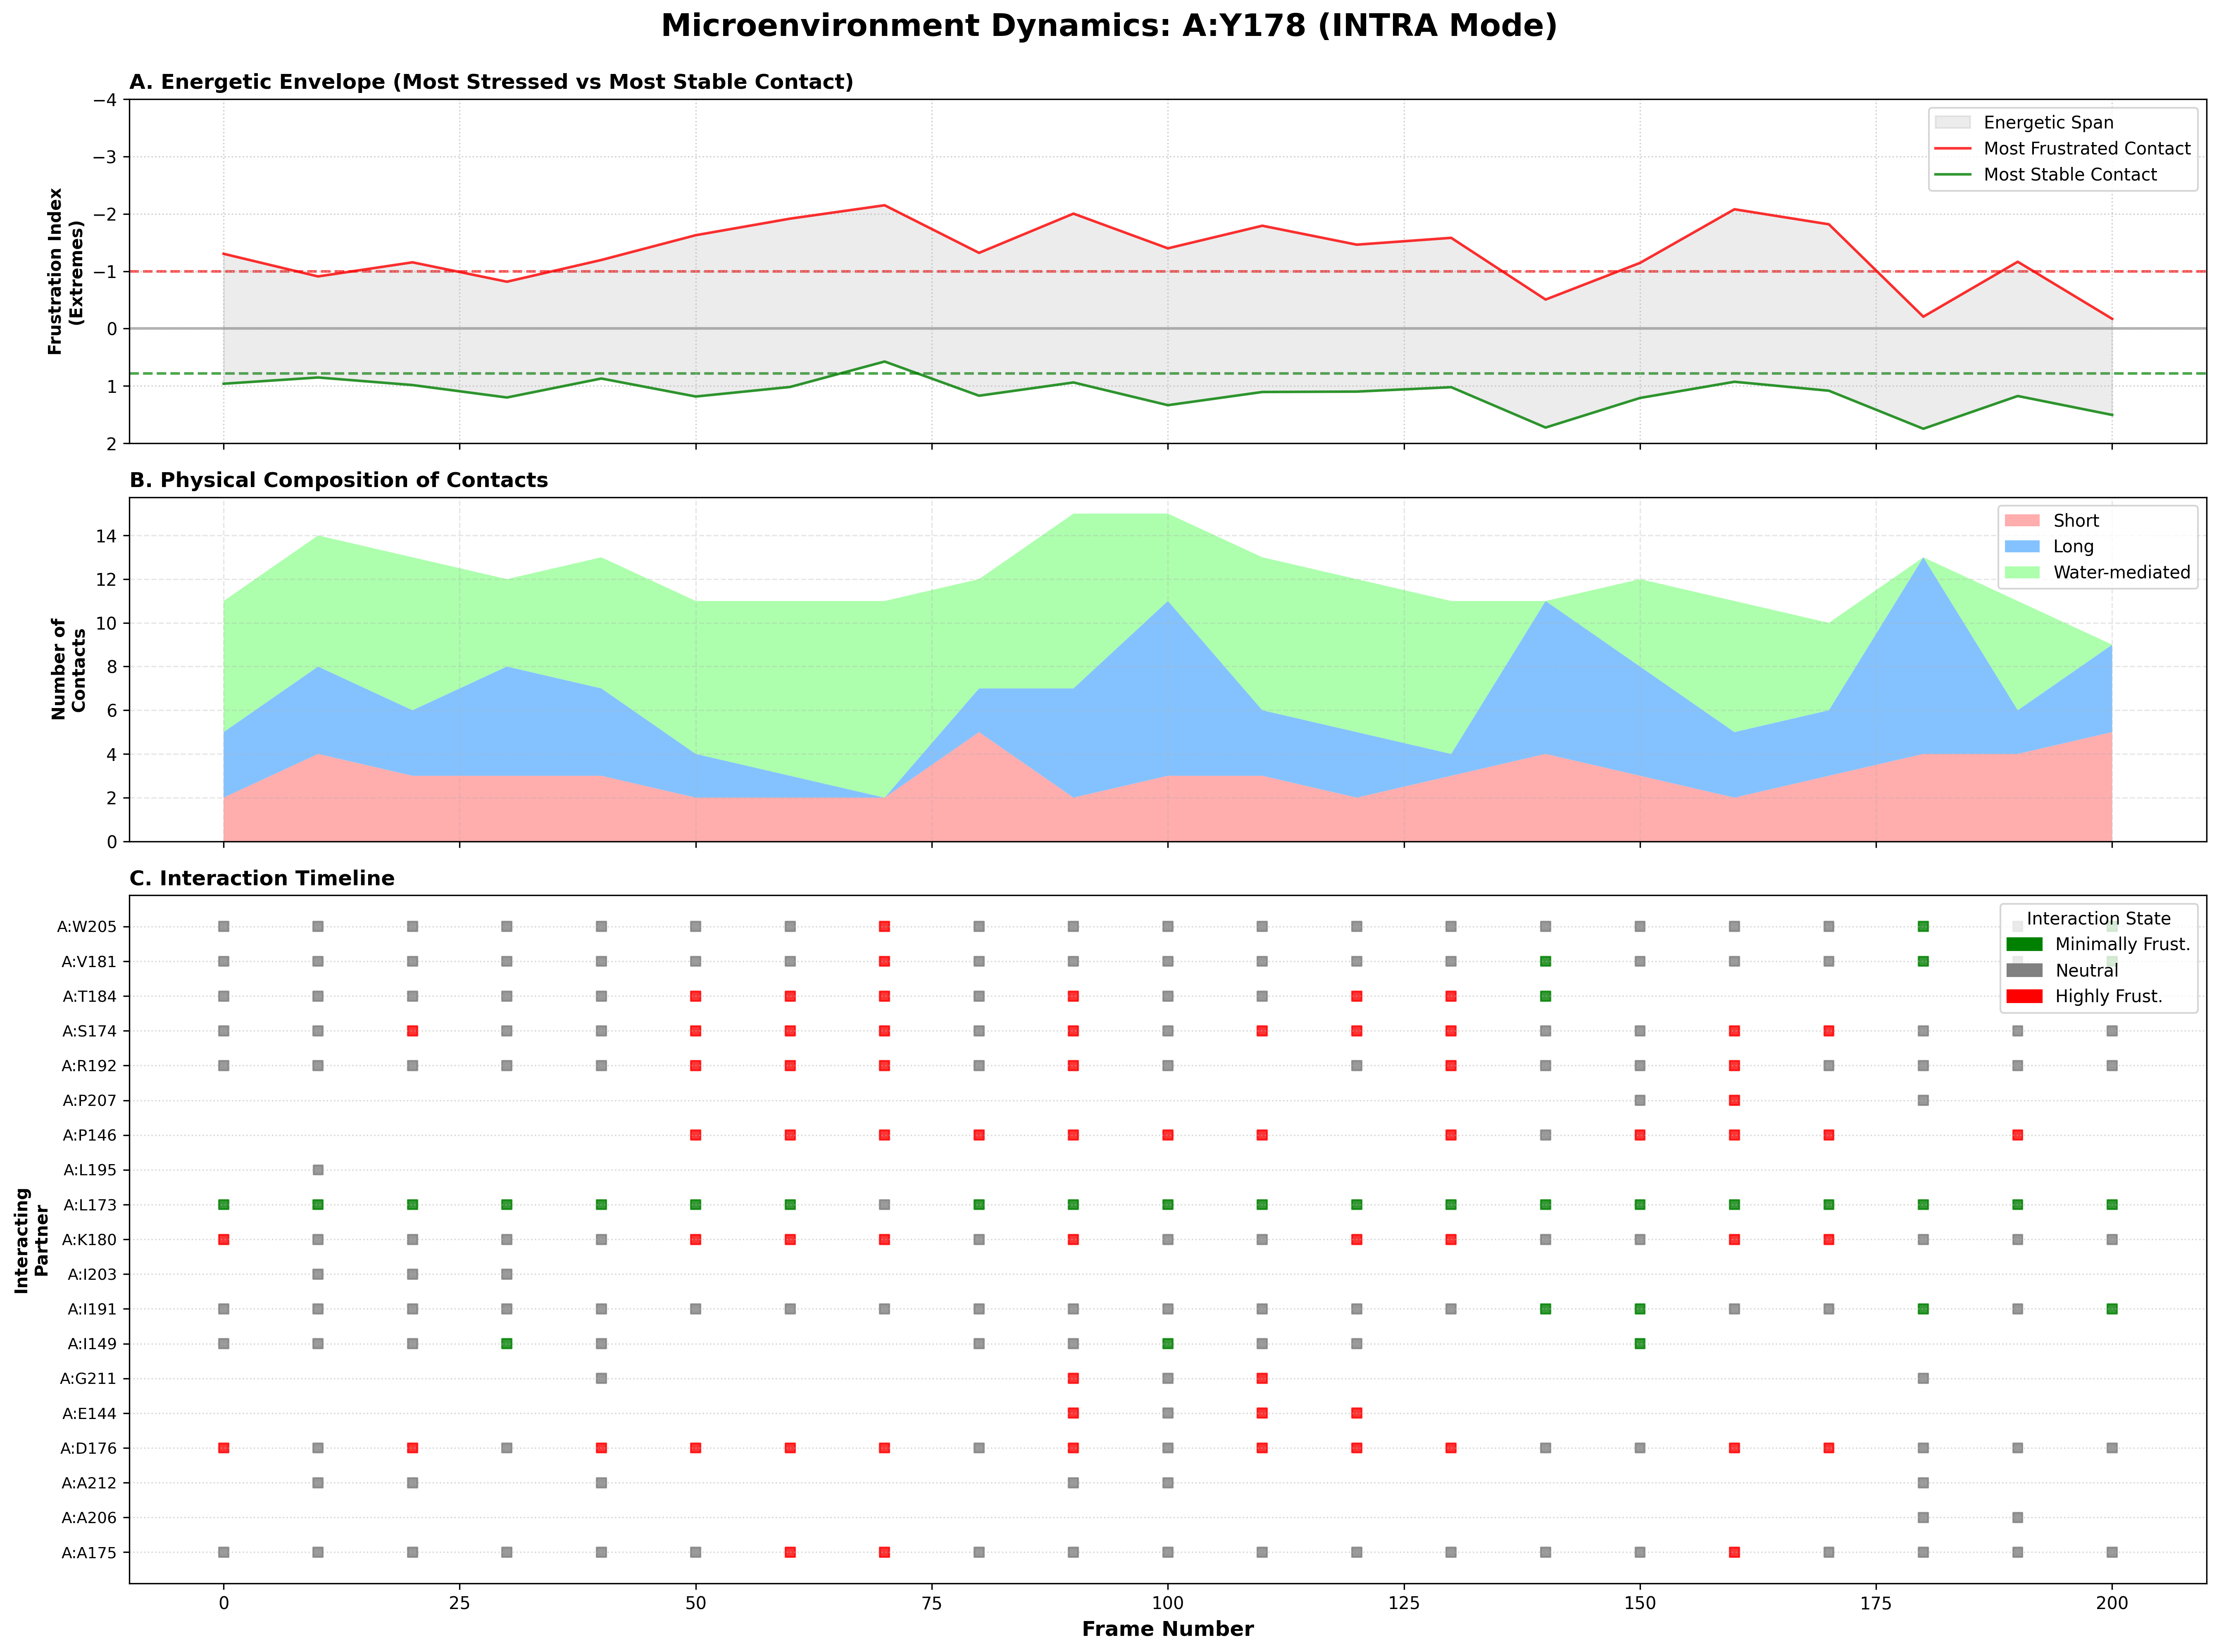

In [15]:
plot_residue_contacts(contacts_df, f'A:{top_residue}', OUT_DIR, 'intra')

Image(filename=f"{OUT_DIR}/contact_dashboard_A_{top_residue}_intra.png")

## 4. 3D Integration: exporting data

2D plots are excellent for quantifying, but allostery must be seen in its 3D context. FrustraMotion allows us to export full biophysical metrics directly into the molecule's B-factor for visualization in VMD or ChimeraX.

In [52]:
# We need to specify where the reference PDB for the Encapsulin is located
# (Make sure this file exists in your example_data folder)
PDB_REFERENCE = f"./example_data/pdb/MtEnc_reference.pdb" 
CXC_OUTPUT = f"./example_data/3d/MtEnc_hotspots_map.cxc"


In [53]:
from frustramotion.io.export_chimerax import generate_chimerax_script
# Generate the Heatmap script for Hotspots
generate_chimerax_script(
    df=single_res_df, 
    pdb_file=PDB_REFERENCE, 
    output_path=CXC_OUTPUT, 
    metric='hotspots', 
    chain_id='A'
)

print(f"\n[+] Script generated. Drag and drop the file '{CXC_OUTPUT}' into your ChimeraX window to see the 3D heatmap.")

 -> ChimeraX 3D Script generated successfully: ./example_data/3d/MtEnc_hotspots_map.cxc

[+] Script generated. Drag and drop the file './example_data/3d/MtEnc_hotspots_map.cxc' into your ChimeraX window to see the 3D heatmap.


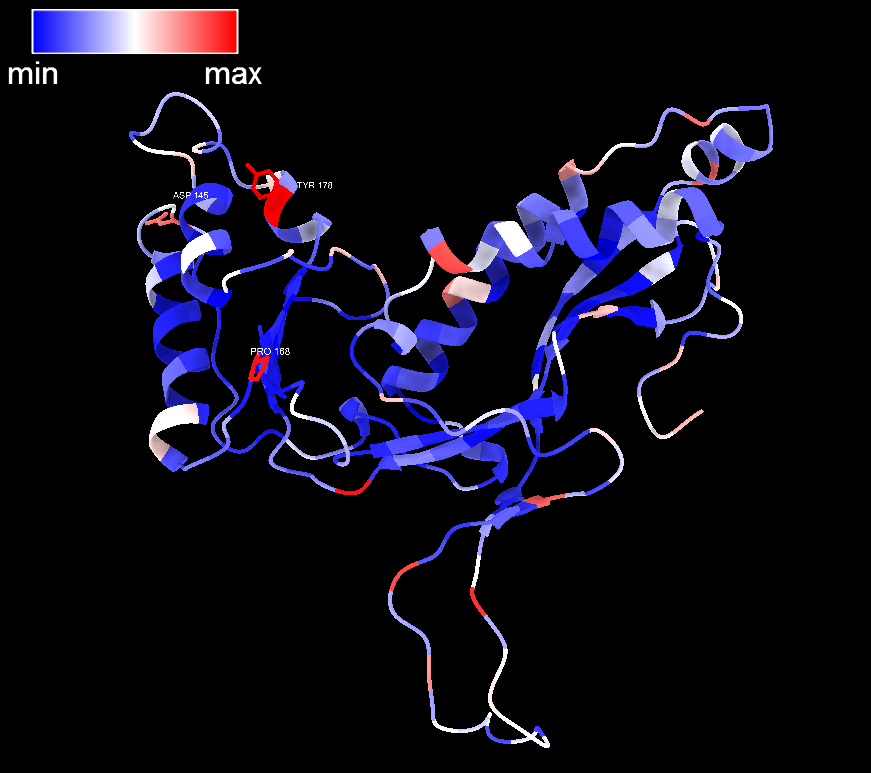

In [55]:
Image(filename=f"figs/image.png")